# Ejercicio 3 — Capital económico con cópulas

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos Matemáticos — Probabilidad y Simulación

---

## Objetivo

Una entidad financiera tiene exposición crediticia en cinco países. Las **pérdidas** anuales de cada país se modelizan como normales (convención: **valor positivo = pérdida**):

| País | Media $\mu$ | Desv. típica $\sigma$ |
|---|---|---|
| Brazil | 10 | 0.75 |
| Chile | 15 | 1.00 |
| France | 18 | 3.00 |
| Italy | 12 | 2.30 |
| Germany | 19 | 4.00 |

El **capital económico** se define como un **percentil (95%)** de la distribución de pérdidas. Se pide:

- **(A)** Capital *stand-alone* de cada país (percentil 95% individual) y su suma (capital sin diversificación).
- **(B)** Índice sintético macroeconómico por país = **primera componente principal** de sus series macro (`series_macro.xlsx`).
- **(C)** Matriz de correlaciones $5\times 5$ entre los índices sintéticos.
- **(D)** Simular la pérdida agregada con **cópula gaussiana** (normal multivariante) y obtener el capital diversificado (percentil 95%).
- **(E)** Repetir con **cópula t de Student** y comparar.
- **(F)** Discutir el impacto de la diversificación y del tipo de cópula.

> **Reproducibilidad.** Semillas fijas; todas las cifras del texto proceden de las celdas ejecutadas.

### Configuración del entorno y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.3, "axes.titleweight": "bold",
})

# ── Constantes del problema ──────────────────────────────────────────────────
SEED  = 42
N_SIM = 1_000_000
NIVEL = 0.95
z95   = norm.ppf(NIVEL)
COUNTRIES = ["Brazil", "Chile", "France", "Italy", "Germany"]
PARAMS = {"Brazil": (10, 0.75), "Chile": (15, 1.00), "France": (18, 3.00),
          "Italy": (12, 2.30), "Germany": (19, 4.00)}
mu  = np.array([PARAMS[c][0] for c in COUNTRIES], float)
sig = np.array([PARAMS[c][1] for c in COUNTRIES], float)

# ── Carga de las series macro ────────────────────────────────────────────────
_df = pd.read_excel("../0-enunciado/series_macro.xlsx", sheet_name="Data")
year_cols = [c for c in _df.columns if "YR" in c]
years = np.array([int(c[:4]) for c in year_cols])

# Diccionario país -> (nombres de series, matriz (n_series, 34))
macro = {}
for c in COUNTRIES:
    sub = _df[_df["Country Name"] == c]
    nombres = [s.split(" (")[0] for s in sub["Series Name"]]
    macro[c] = (nombres, sub[year_cols].values.astype(float))

print(f"Años: {years.min()}-{years.max()} ({len(years)} observaciones)")
print("Series disponibles por país:")
for c in COUNTRIES:
    print(f"  {c:8}: {macro[c][1].shape[0]} series -> {', '.join(macro[c][0])}")

Años: 1991-2024 (34 observaciones)
Series disponibles por país:
  Brazil  : 4 series -> GDP growth, Inflation, GDP deflator, Unemployment, total, Deposit interest rate
  Chile   : 4 series -> GDP growth, Inflation, GDP deflator, Unemployment, total, Deposit interest rate
  France  : 3 series -> GDP growth, Inflation, GDP deflator, Unemployment, total
  Italy   : 3 series -> GDP growth, Inflation, GDP deflator, Unemployment, total
  Germany : 3 series -> GDP growth, Inflation, GDP deflator, Unemployment, total


> **Nota sobre los datos.** Brazil y Chile disponen de **4** series (incluyen el *tipo de interés de depósito*); Francia, Italia y Alemania solo de **3** (ese tipo no se publica para la eurozona en la fuente IMF/IFS). No hay valores ausentes. La PCA de cada país se hace sobre las series **realmente disponibles**: la primera componente principal queda igualmente bien definida.

---
## Apartado A — Capital stand-alone

Si la pérdida de un país es $L_i\sim N(\mu_i,\sigma_i^2)$, su capital económico al 95% es el percentil correspondiente (VaR):

$$\text{Capital}_i = \mu_i + \sigma_i\,z_{0.95}, \qquad z_{0.95}=\Phi^{-1}(0.95)\approx 1.6449$$

El **capital stand-alone** de la entidad es la **suma** de los capitales individuales; equivale a suponer que las pérdidas se realizan simultáneamente en su peor escenario, es decir, **ausencia total de diversificación**.

In [2]:
cap_sa = mu + sig * z95                       # percentil 95% de cada país
suma_sa = cap_sa.sum()

tabla_sa = pd.DataFrame({"mu": mu, "sigma": sig, "Capital 95% (VaR)": cap_sa}, index=COUNTRIES)
print(tabla_sa.round(3).to_string())
print(f"\nCapital STAND-ALONE (suma, sin diversificación) = {suma_sa:.3f}")
print(f"Pérdida esperada total (suma de mu)             = {mu.sum():.3f}")
print(f"Capital por riesgo inesperado (z95 * suma sigma) = {z95*sig.sum():.3f}")

           mu  sigma  Capital 95% (VaR)
Brazil   10.0   0.75             11.234
Chile    15.0   1.00             16.645
France   18.0   3.00             22.935
Italy    12.0   2.30             15.783
Germany  19.0   4.00             25.579

Capital STAND-ALONE (suma, sin diversificación) = 92.176
Pérdida esperada total (suma de mu)             = 74.000
Capital por riesgo inesperado (z95 * suma sigma) = 18.176


---
## Apartado B — Índice sintético macroeconómico por país (PCA)

Para estimar la dependencia entre países usamos sus series macro. Para cada país construimos un **índice sintético** como la **primera componente principal (PC1)** de sus series.

**Procedimiento (por país):**
1. Disponer los datos como matriz $X$ de $34$ años $\times$ $k$ series.
2. **Estandarizar** cada serie (restar media, dividir por desviación típica). Es imprescindible porque las series tienen escalas muy dispares (p. ej. la hiperinflación brasileña de los 90 alcanza miles de %): así la PCA se basa en la **matriz de correlación** y no la dominan las series de mayor varianza.
3. Calcular la PCA vía **SVD** de la matriz estandarizada $X_s = U\,S\,V^\top$. La primera componente principal (los *scores*) es $\text{PC1}=U_{\cdot,1}\,S_{1}$, una serie temporal de 34 valores.
4. **Fijar el signo** (la PCA lo deja indeterminado): por reproducibilidad orientamos cada PC1 para que su correlación con el crecimiento del PIB sea **positiva**. Es solo una **convención** que hace los índices comparables entre países; **no** garantiza que PC1 mida "fortaleza económica" — de hecho su significado varía según el país, como veremos.

El cociente $S_1^2/\sum S^2$ es la **proporción de varianza explicada** (EVR) por PC1.

In [3]:
def pca_indice(M):
    """Primera componente principal de una matriz (n_series, n_años).
    Devuelve (scores PC1 estandarizados, cargas, EVR)."""
    X = M.T                                   # (años, series)
    Xs = (X - X.mean(0)) / X.std(0, ddof=0)   # estandarizar cada serie
    U, S, Vt = np.linalg.svd(Xs, full_matrices=False)
    scores = U[:, 0] * S[0]                    # PC1 (serie temporal)
    cargas = Vt[0]                             # pesos de cada serie en PC1
    # Signo: PC1 debe correlacionar positivamente con el PIB (serie 0)
    if np.corrcoef(scores, Xs[:, 0])[0, 1] < 0:
        scores, cargas = -scores, -cargas
    evr = S[0]**2 / np.sum(S**2)
    return scores, cargas, evr

indices, evrs = {}, {}
print("PCA por país (primera componente principal):\n")
for c in COUNTRIES:
    nombres, M = macro[c]
    scores, cargas, evr = pca_indice(M)
    indices[c] = scores
    evrs[c] = evr
    cargas_txt = ", ".join(f"{n.split(',')[0]}={w:+.2f}" for n, w in zip(nombres, cargas))
    print(f"  {c:8} (EVR PC1 = {evr:5.1%}):  {cargas_txt}")

PCA por país (primera componente principal):

  Brazil   (EVR PC1 = 59.7%):  GDP growth=+0.28, Inflation=+0.61, Unemployment=-0.43, Deposit interest rate=+0.60
  Chile    (EVR PC1 = 59.8%):  GDP growth=+0.46, Inflation=+0.46, Unemployment=-0.53, Deposit interest rate=+0.55
  France   (EVR PC1 = 55.2%):  GDP growth=+0.31, Inflation=-0.67, Unemployment=+0.67
  Italy    (EVR PC1 = 37.8%):  GDP growth=+0.53, Inflation=+0.78, Unemployment=-0.34
  Germany  (EVR PC1 = 52.9%):  GDP growth=+0.26, Inflation=-0.70, Unemployment=+0.67


Las **cargas** (y la correlación del índice con cada serie cruda) revelan que **PC1 no significa lo mismo en todos los países**:

- En **Brazil y Chile** PC1 captura un eje *inflación–tipos–actividad* (inflación y tipos altos, paro bajo). En **Brazil** está además **dominado por la hiperinflación de 1991–1994** —esos años marcan el pico del índice (corr ≈ 0.8 con el periodo 91–94)—, por lo que funciona casi como un indicador de régimen.
- En **France y Germany** PC1 está gobernado por el contraste **inflación↓ / paro↑** (la carga del PIB es minoritaria): un índice alto refleja **más paro**, no necesariamente "fortaleza económica".

Por tanto PC1 es el **primer factor común** de cada bloque macro, no un índice homogéneo de fortaleza. La **EVR** confirma que resume bien a Brazil/Chile (~60%) pero peor a **Italia (~38%)**, cuyas 3 series están poco correlacionadas. Conviene tenerlo presente al leer la matriz de correlaciones. Visualizamos los cinco índices a lo largo del tiempo.

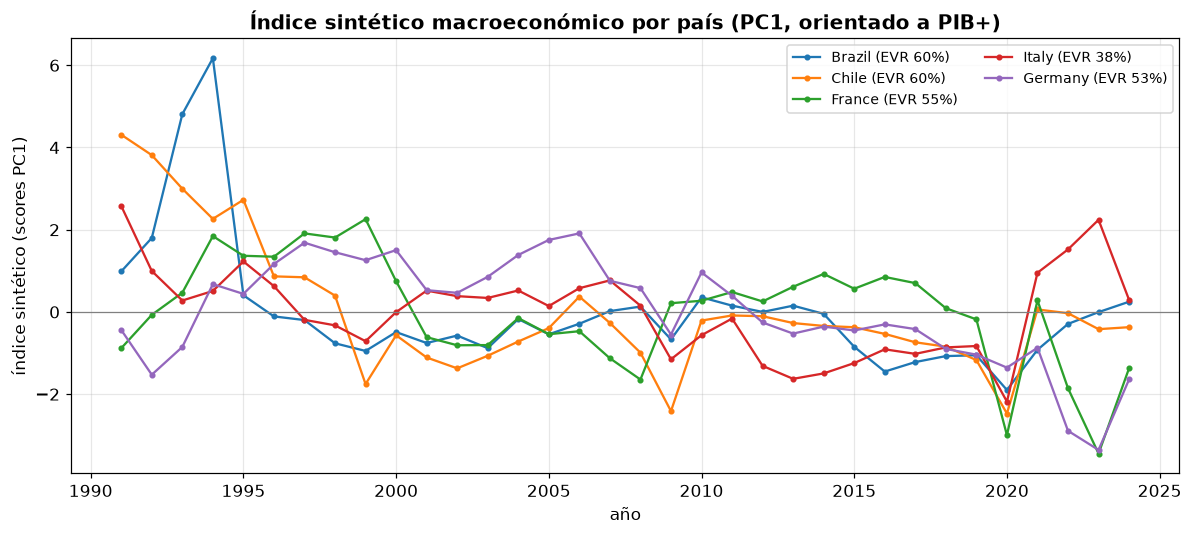

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
for c in COUNTRIES:
    ax.plot(years, indices[c], marker="o", ms=3, lw=1.5, label=f"{c} (EVR {evrs[c]:.0%})")
ax.axhline(0, color="grey", lw=0.8)
ax.set(title="Índice sintético macroeconómico por país (PC1, orientado a PIB+)",
       xlabel="año", ylabel="índice sintético (scores PC1)")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig("resultados/grafico_3b_indices_sinteticos.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Apartado C — Matriz de correlaciones entre países

La estructura de dependencia entre geografías se estima como la **correlación de Pearson** entre los índices sintéticos. Apilamos los cinco índices en una matriz $34\times 5$ y calculamos su matriz de correlación $R$ ($5\times 5$).

In [5]:
IDX = np.column_stack([indices[c] for c in COUNTRIES])   # (34, 5)
R = np.corrcoef(IDX, rowvar=False)

# Comprobación: R debe ser definida positiva (necesario para Cholesky)
autovalores = np.linalg.eigvalsh(R)
assert np.all(autovalores > 0), "R no es definida positiva"

print("Matriz de correlaciones R (índices sintéticos):\n")
print(pd.DataFrame(R, index=COUNTRIES, columns=COUNTRIES).round(3).to_string())
print(f"\nAutovalores de R: {autovalores.round(3)}  -> todos > 0 (definida positiva)")

Matriz de correlaciones R (índices sintéticos):

         Brazil  Chile  France  Italy  Germany
Brazil    1.000  0.674   0.205  0.316   -0.024
Chile     0.674  1.000   0.241  0.562   -0.031
France    0.205  0.241   1.000 -0.284    0.544
Italy     0.316  0.562  -0.284  1.000   -0.112
Germany  -0.024 -0.031   0.544 -0.112    1.000

Autovalores de R: [0.169 0.377 0.729 1.66  2.065]  -> todos > 0 (definida positiva)


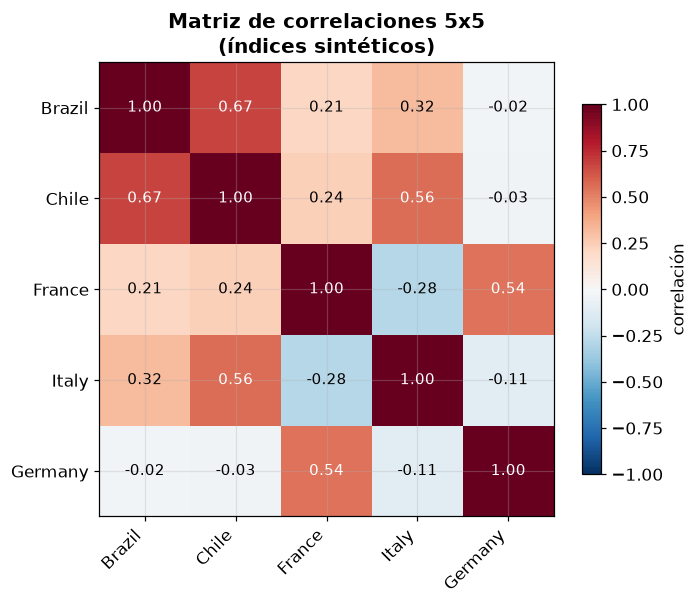

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(COUNTRIES, rotation=45, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(COUNTRIES)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{R[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(R[i, j]) > 0.5 else "black", fontsize=10)
ax.set_title("Matriz de correlaciones 5x5\n(índices sintéticos)")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlación")
plt.tight_layout()
plt.savefig("resultados/grafico_3c_matriz_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

La matriz $R$ muestra bloques como **Brazil–Chile** y **France–Germany** (positivos) y algún signo negativo (Italia–Francia). Antes de usarla conviene tener presentes tres advertencias de rigor:

1. Los **signos** de $R$ dependen de la convención de signo de PC1. Al fijarla igual para todos (orientación a PIB$\uparrow$) son **coherentes entre países**, pero no "absolutos".
2. Con solo **34 observaciones**, el error típico de cada correlación es $\approx 1/\sqrt{n-3}\approx 0.18$: las correlaciones pequeñas **no son distinguibles de 0**.
3. Como PC1 mezcla ejes distintos según el país (ver arriba), $R$ es un **constructo estadístico**, no una "correlación del ciclo" limpia.

A continuación cuantificamos (i) qué correlaciones son significativas y (ii) cuánto afectan estas advertencias al capital final.

In [7]:
from itertools import product

# (i) Significancia de las correlaciones (n=34 observaciones)
n = len(years)
se_r = 1 / np.sqrt(n - 3)          # error típico aproximado de una correlación
umbral = 2 * se_r                  # ~2 errores típicos
signif = [f"{COUNTRIES[i][:3]}-{COUNTRIES[j][:3]}={R[i, j]:+.2f}"
          for i in range(5) for j in range(i+1, 5) if abs(R[i, j]) > umbral]
print(f"(i) Significancia (n={n}): SE(r) ~ {se_r:.2f}  ->  |r| significativo si > {umbral:.2f}")
print(f"    Correlaciones significativas: {', '.join(signif)}")
print(f"    (las demás no son distinguibles de 0)")

# (ii) Sensibilidad del capital diversificado a la convención de signo de PC1.
#     Cambiar el signo de un índice equivale a R -> D R D con D=diag(±1).
caps_conv = np.array([mu.sum() + z95 * np.sqrt(sig @ (R*np.outer(s, s)) @ sig)
                      for s in product([1, -1], repeat=5)])
print(f"\n(ii) Capital diversificado (analítico) sobre las 2^5=32 convenciones de signo:")
print(f"     rango = [{caps_conv.min():.1f}, {caps_conv.max():.1f}]   "
      f"(nuestra convención PIB+ = {mu.sum()+z95*np.sqrt(sig@R@sig):.1f})")
print(f"     ¿todas por debajo del stand-alone ({suma_sa:.1f})?  {bool(caps_conv.max() < suma_sa)}")
print("     -> La DIVERSIFICACIÓN es robusta a la convención; el valor exacto, no tanto.")

(i) Significancia (n=34): SE(r) ~ 0.18  ->  |r| significativo si > 0.36
    Correlaciones significativas: Bra-Chi=+0.67, Chi-Ita=+0.56, Fra-Ger=+0.54
    (las demás no son distinguibles de 0)

(ii) Capital diversificado (analítico) sobre las 2^5=32 convenciones de signo:
     rango = [79.6, 86.0]   (nuestra convención PIB+ = 85.1)
     ¿todas por debajo del stand-alone (92.2)?  True
     -> La DIVERSIFICACIÓN es robusta a la convención; el valor exacto, no tanto.


---
## Apartado D — Capital diversificado: cópula gaussiana (normal multivariante)

Modelizamos el vector de pérdidas como **normal multivariante** con las marginales dadas y la correlación $R$ estimada. Equivale a unir las marginales $N(\mu_i,\sigma_i)$ con una **cópula gaussiana** de matriz $R$.

**Simulación** (descomposición de Cholesky $R=LL^\top$):
1. $Z = L\,\varepsilon$, con $\varepsilon\sim N(0,I)$ → vector normal estándar correlacionado, $\text{Corr}(Z)=R$.
2. $L_i = \mu_i + \sigma_i Z_i$ → pérdidas con marginales correctas y correlación $R$.
3. Pérdida agregada $L_{\text{tot}}=\sum_i L_i$; el capital diversificado es su **percentil 95%**.

**Comprobación analítica:** la suma de normales correlacionadas es normal, $L_{\text{tot}}\sim N\!\big(\textstyle\sum\mu_i,\ \sigma_{\text{tot}}^2\big)$ con $\sigma_{\text{tot}}=\sqrt{\sigma^\top R\,\sigma}$, luego el percentil exacto es $\sum\mu_i + z_{0.95}\,\sigma_{\text{tot}}$.

In [8]:
Lchol = np.linalg.cholesky(R)
rng = np.random.default_rng(SEED)

# 1) normales estándar correlacionadas  2) marginales  3) agregado
Z = (Lchol @ rng.standard_normal((5, N_SIM))).T
L_gauss = mu + sig * Z
tot_gauss = L_gauss.sum(axis=1)
cap_gauss = np.percentile(tot_gauss, 95)

# Comprobación analítica
sig_tot = np.sqrt(sig @ R @ sig)
cap_gauss_an = mu.sum() + z95 * sig_tot

print("Cópula gaussiana (normal multivariante):")
print(f"  sigma_total = sqrt(sigmaT R sigma) = {sig_tot:.3f}   (suma sigma = {sig.sum():.3f} si corr. perfecta)")
print(f"  Capital diversificado 95% - simulado  = {cap_gauss:.3f}")
print(f"  Capital diversificado 95% - analítico = {cap_gauss_an:.3f}")
print(f"  (error de simulación = {abs(cap_gauss-cap_gauss_an):.4f})")

Cópula gaussiana (normal multivariante):
  sigma_total = sqrt(sigmaT R sigma) = 6.752   (suma sigma = 11.050 si corr. perfecta)
  Capital diversificado 95% - simulado  = 85.101
  Capital diversificado 95% - analítico = 85.106
  (error de simulación = 0.0053)


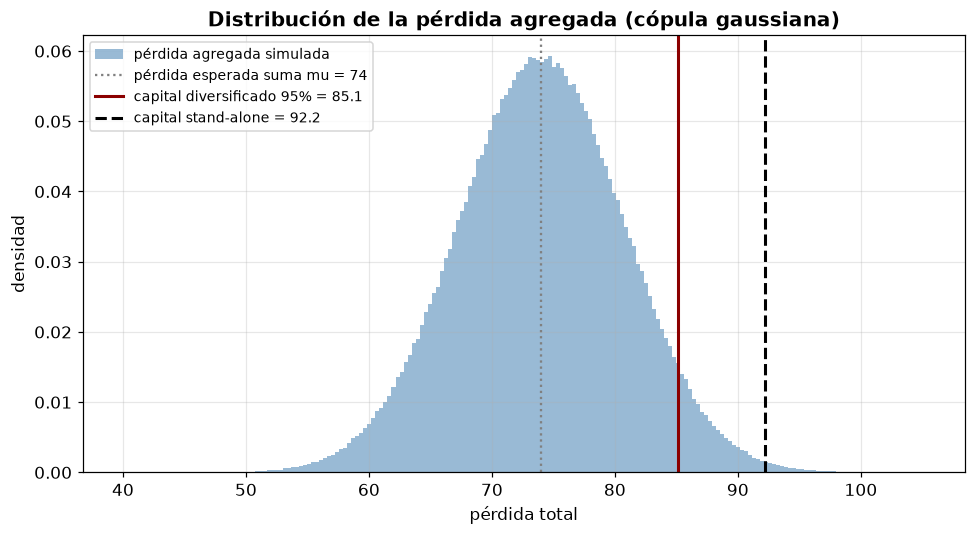

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tot_gauss, bins=200, density=True, alpha=0.55, color="steelblue",
        label="pérdida agregada simulada")
ax.axvline(mu.sum(), color="grey", lw=1.5, ls=":", label=f"pérdida esperada suma mu = {mu.sum():.0f}")
ax.axvline(cap_gauss, color="darkred", lw=2,
           label=f"capital diversificado 95% = {cap_gauss:.1f}")
ax.axvline(suma_sa, color="black", lw=2, ls="--",
           label=f"capital stand-alone = {suma_sa:.1f}")
ax.set(title="Distribución de la pérdida agregada (cópula gaussiana)",
       xlabel="pérdida total", ylabel="densidad")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("resultados/grafico_3d_distribucion_perdidas.png", dpi=150, bbox_inches="tight")
plt.show()

El capital diversificado (línea roja) queda **a la izquierda** del stand-alone (línea negra discontinua): la diversificación reduce el capital porque las pérdidas no se realizan todas en su peor escenario a la vez.

---
## Apartado E — Capital diversificado: cópula t de Student

La cópula gaussiana **no tiene dependencia en las colas**: los eventos extremos conjuntos son raros. La **cópula t de Student** sí presenta **dependencia de colas**, es decir, mayor probabilidad de que varios países sufran pérdidas extremas **a la vez**. Mantenemos las **mismas marginales** $N(\mu_i,\sigma_i)$ y la **misma** matriz $R$ para aislar el efecto del tipo de cópula.

**Simulación de la cópula t con $\nu$ grados de libertad:**
1. $Z = L\,\varepsilon$ (como antes) y $W\sim\chi^2_\nu/\nu$ independiente.
2. $T = Z/\sqrt{W}$ → vector **t multivariante** con matriz de forma $R$.
3. $U_i = F_{t,\nu}(T_i)$ → uniformes acopladas por la cópula t.
4. $L_i = \Phi^{-1}(U_i)\,\sigma_i+\mu_i$ → marginales normales con dependencia t.

Cuanto **menor** es $\nu$, más pesadas son las colas y más fuerte la dependencia de colas ($\nu\to\infty$ recupera la gaussiana).

In [10]:
def simular_t_copula(nu, semilla=7, return_L=False):
    rng = np.random.default_rng(semilla)
    Z = (Lchol @ rng.standard_normal((5, N_SIM))).T
    W = rng.chisquare(nu, N_SIM) / nu
    T = Z / np.sqrt(W)[:, None]
    U = np.clip(t.cdf(T, nu), 1e-12, 1 - 1e-12)   # uniformes (clip defensivo)
    L = norm.ppf(U) * sig + mu                     # marginales normales
    return L if return_L else L.sum(axis=1)

NU = 4                                              # grados de libertad de referencia
tot_t = simular_t_copula(NU)
cap_t = np.percentile(tot_t, 95)

# Verificación: con matriz de forma R, la cópula t debe reproducir R en las marginales
R_real = np.corrcoef(simular_t_copula(NU, return_L=True), rowvar=False)
print(f"Cópula t de Student (nu={NU}):")
print(f"  Capital diversificado 95% = {cap_t:.3f}   (gaussiana 95% = {cap_gauss:.3f})")
print(f"  Verificación: max|Corr realizada - R| = {np.abs(R_real-R).max():.3f}  (la t respeta R)")

Cópula t de Student (nu=4):
  Capital diversificado 95% = 84.982   (gaussiana 95% = 85.101)
  Verificación: max|Corr realizada - R| = 0.009  (la t respeta R)


### Dependencia de colas: el efecto crece al adentrarse en la cola

A percentil 95% la diferencia entre cópulas es **pequeña** (95% no es un cuantil muy extremo). El efecto de la dependencia de colas se hace patente al mirar percentiles más altos (99%, 99.9%). Lo cuantificamos variando $\nu$.

In [11]:
niveles = [95, 99, 99.9]
filas = []
filas.append(["Gaussiana (nu->inf)"] + [np.percentile(tot_gauss, q) for q in niveles])
for nu in [30, 10, 4, 3]:
    tt = simular_t_copula(nu)
    filas.append([f"t, nu={nu}"] + [np.percentile(tt, q) for q in niveles])

tabla_colas = pd.DataFrame(filas, columns=["Cópula", "VaR 95%", "VaR 99%", "VaR 99.9%"]).set_index("Cópula")
print("Capital diversificado según cópula y nivel de confianza:\n")
print(tabla_colas.round(2).to_string())
print("\n-> A 95% apenas cambia; en la cola profunda (99.9%) la cópula t exige")
print("   mucho más capital cuanto menor es nu (más dependencia de colas).")

Capital diversificado según cópula y nivel de confianza:

                     VaR 95%  VaR 99%  VaR 99.9%
Cópula                                          
Gaussiana (nu->inf)    85.10    89.73      94.86
t, nu=30               85.11    89.89      95.49
t, nu=10               85.07    90.15      96.45
t, nu=4                84.98    90.66      98.55
t, nu=3                84.91    90.96      99.38

-> A 95% apenas cambia; en la cola profunda (99.9%) la cópula t exige
   mucho más capital cuanto menor es nu (más dependencia de colas).


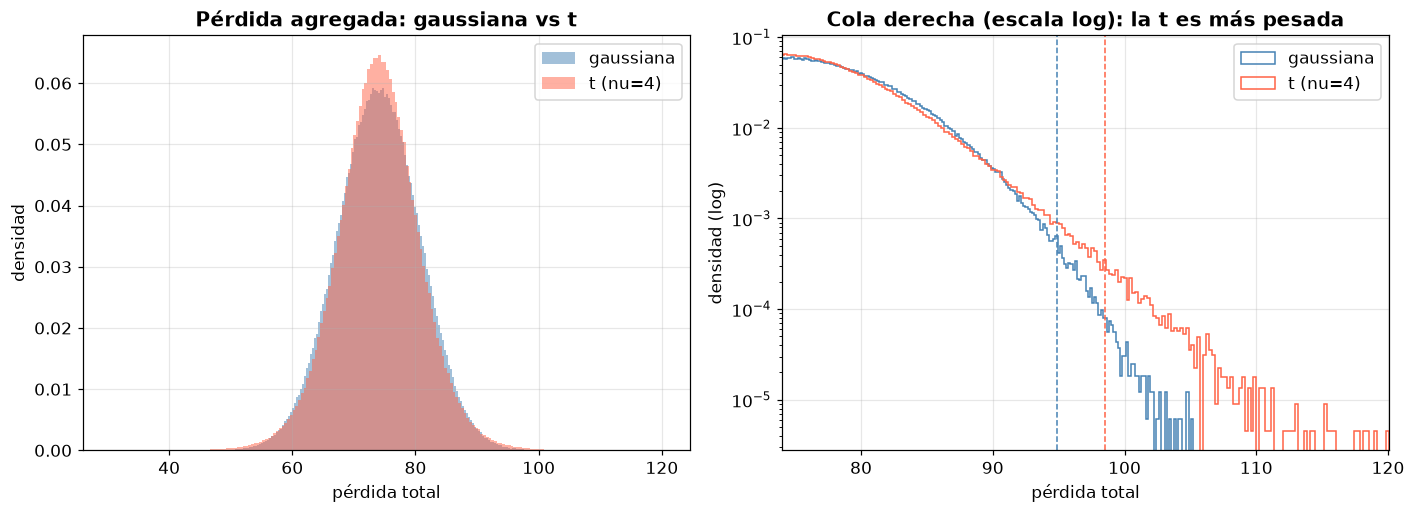

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
# Panel 1: densidades agregadas
axes[0].hist(tot_gauss, bins=200, density=True, alpha=0.5, color="steelblue", label="gaussiana")
axes[0].hist(tot_t, bins=200, density=True, alpha=0.5, color="tomato", label=f"t (nu={NU})")
axes[0].set(title="Pérdida agregada: gaussiana vs t", xlabel="pérdida total", ylabel="densidad")
axes[0].legend()
# Panel 2: zoom en la cola derecha (escala log)
axes[1].hist(tot_gauss, bins=400, density=True, histtype="step", color="steelblue", label="gaussiana")
axes[1].hist(tot_t, bins=400, density=True, histtype="step", color="tomato", label=f"t (nu={NU})")
axes[1].set_yscale("log")
axes[1].set_xlim(mu.sum(), tot_t.max())
axes[1].axvline(np.percentile(tot_gauss, 99.9), color="steelblue", ls="--", lw=1)
axes[1].axvline(np.percentile(tot_t, 99.9), color="tomato", ls="--", lw=1)
axes[1].set(title="Cola derecha (escala log): la t es más pesada",
            xlabel="pérdida total", ylabel="densidad (log)")
axes[1].legend()
plt.tight_layout()
plt.savefig("resultados/grafico_3e_gauss_vs_t.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Apartado F — Discusión: diversificación e impacto de la cópula

Reunimos los tres capitales y descomponemos el efecto.

In [13]:
EL = mu.sum()                                  # pérdida esperada (no diversifica)
resumen = pd.DataFrame({
    "Capital 95%": [suma_sa, cap_gauss, cap_t],
    "Riesgo inesperado (VaR-EL)": [suma_sa-EL, cap_gauss-EL, cap_t-EL],
}, index=["Stand-alone (sin diversif.)", "Diversif. gaussiana", f"Diversif. t (nu={NU})"])
resumen["Ahorro vs stand-alone"] = suma_sa - resumen["Capital 95%"]
resumen["Ahorro %"] = 100 * resumen["Ahorro vs stand-alone"] / suma_sa

print("=" * 72)
print("RESUMEN — Capital económico (percentil 95%)")
print("=" * 72)
print(resumen.round(2).to_string())
print(f"\nPérdida esperada (suma mu) = {EL:.1f}  (componente que NO diversifica)")
print(f"Diversificación sobre el riesgo inesperado (gaussiana): "
      f"{100*(1-(cap_gauss-EL)/(suma_sa-EL)):.1f}%")

RESUMEN — Capital económico (percentil 95%)
                             Capital 95%  Riesgo inesperado (VaR-EL)  Ahorro vs stand-alone  Ahorro %
Stand-alone (sin diversif.)        92.18                       18.18                   0.00      0.00
Diversif. gaussiana                85.10                       11.10                   7.07      7.67
Diversif. t (nu=4)                 84.98                       10.98                   7.19      7.80

Pérdida esperada (suma mu) = 74.0  (componente que NO diversifica)
Diversificación sobre el riesgo inesperado (gaussiana): 38.9%


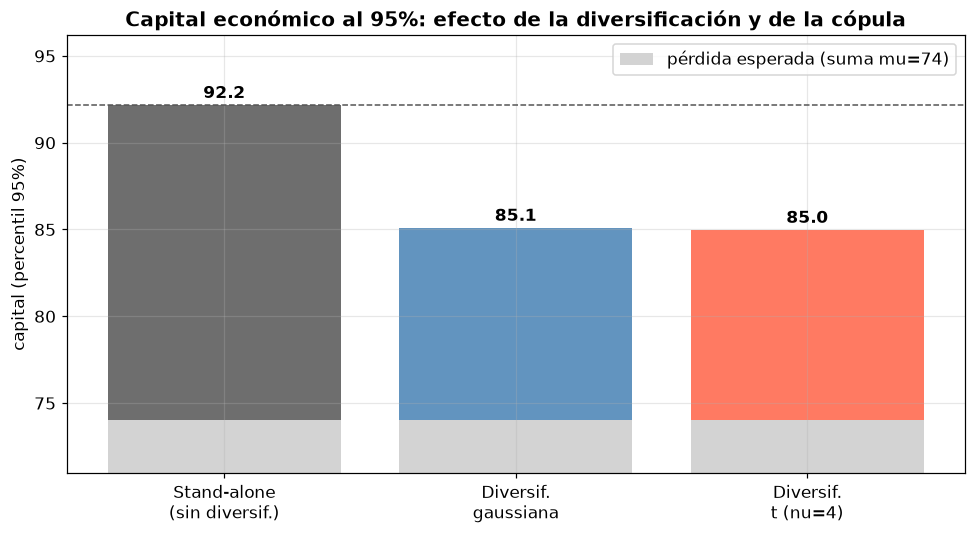

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
etiquetas = ["Stand-alone\n(sin diversif.)", "Diversif.\ngaussiana", f"Diversif.\nt (nu={NU})"]
valores = [suma_sa, cap_gauss, cap_t]
colores = ["#555555", "steelblue", "tomato"]
barras = ax.bar(etiquetas, valores, color=colores, alpha=0.85)
ax.bar(etiquetas, [EL]*3, color="lightgrey", label=f"pérdida esperada (suma mu={EL:.0f})")
ax.axhline(suma_sa, color="#555555", ls="--", lw=1)
for b, v in zip(barras, valores):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}", ha="center", fontweight="bold")
ax.set(title="Capital económico al 95%: efecto de la diversificación y de la cópula",
       ylabel="capital (percentil 95%)", ylim=(EL-3, suma_sa+4))
ax.legend()
plt.tight_layout()
plt.savefig("resultados/grafico_3f_comparativa_capital.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Conclusiones

> Todas las cifras proceden de las celdas ejecutadas (semillas fijas).

**Pipeline.** `series_macro.xlsx` → PCA por país (índice sintético) → matriz de correlaciones $5\times5$ → simulación de pérdidas (cópula gaussiana y t) → capital diversificado al 95%.

**A. Stand-alone.** Sumando los percentiles individuales, el capital sin diversificación es **≈ 92.2**. De ese total, la **pérdida esperada** $\Sigma\mu=74$ no diversifica; solo el riesgo inesperado ($z_{0.95}\Sigma\sigma\approx 18.2$) es diversificable.

**B–C. Estructura de dependencia.** El índice sintético (PC1) es el **primer factor común** de cada bloque macro (EVR ~38%–60%), pero **su significado varía por país** (eje inflación–tipos en Brazil/Chile, dominado por la hiperinflación; contraste inflación↓/paro↑ en France/Germany). Por ello $R$ es un **constructo estadístico**, no una "correlación del ciclo" limpia: con solo 34 datos las correlaciones pequeñas no son significativas (solo Brazil–Chile, Chile–Italia y France–Germany superan el ruido) y sus **signos dependen de la convención de signo de PC1**. Aun así, $R$ es definida positiva y muestra bloques razonables.

**D. Cópula gaussiana.** El capital diversificado al 95% es **≈ 85.1**, validado analíticamente ($\sum\mu+z_{0.95}\sqrt{\sigma^\top R\sigma}$). La diversificación **ahorra ≈ 7.7%** del capital total (y **≈ 39%** del riesgo inesperado), porque $\sigma_{\text{tot}}=\sqrt{\sigma^\top R\sigma}\approx 6.75 < \Sigma\sigma=11.05$: al no estar perfectamente correlacionadas, las pérdidas no alcanzan su peor escenario simultáneamente.

**E. Cópula t de Student.** Con las **mismas** marginales y la **misma** $R$ (que la cópula t respeta: correlación realizada ≈ $R$), a percentil 95% el capital es **casi idéntico** al gaussiano (95% no es un cuantil extremo). Sin embargo, la cópula t tiene **dependencia de colas**: al avanzar hacia la cola (99%, 99.9%) exige **bastante más** capital, tanto más cuanto menor es $\nu$. Es decir, **el tipo de cópula es casi irrelevante a 95% pero decisivo para riesgos extremos**.

**F. Lecturas finales.**
- La **diversificación** reduce el capital de forma tangible, pero solo actúa sobre el riesgo inesperado; la pérdida esperada permanece.
- La conclusión de diversificación es **robusta**: recalculando el capital para las $2^5=32$ convenciones de signo de los índices, **siempre** resulta inferior al stand-alone (92.2). Lo que sí depende de la convención (y del ruido de estimación de $R$ con $n=34$) es el **valor exacto**, que se mueve en una banda de pocos puntos — conviene reportarlo con esa cautela.
- La **elección de cópula** no cambia la media ni (apenas) los cuantiles moderados, pero gobierna el comportamiento en la **cola**: subestimarla (usar gaussiana cuando hay dependencia de colas) infravalora el capital para sucesos severos. Por prudencia, a niveles de confianza altos (99.9%) conviene una cópula con colas (t) o un análisis de sensibilidad en $\nu$.
- Para distribuciones elípticas (gaussiana y t) el VaR es **subaditivo**, por lo que la diversificación nunca penaliza; en modelos con colas muy asimétricas esto podría no cumplirse.